# Proyecto de Machine Learning: Bank Marketing


**Creadores:**

- Juan Manuel Gomez
- Miguel Angel Hoyos
- Jehison Cifuentes Cortes


## XGBoost

**Objetivo del Negocio:** Nos enfrentamos a un problema de clasificación binaria. El objetivo principal es predecir si un cliente aceptará o no un depósito a término fijo (variable objetivo `y`).

---
## Tabla de Contenido

1. Comprensión del Negocio
2. Imports y Configuración
3. Helper Functions
4. Carga del Dataset
5. Auditoría Temprana y Calidad de Datos
   - Descripción Numérica Rápida
   - Cardinalidad y Duplicados
   - Valores Faltantes Explícitos e Implícitos
   - Conclusiones sobre Calidad de Datos
   - Preparación de Datos
6. Pipeline de Preparación de Datos
   - Feature Engineering: reglas de preparación del dominio
   - Definir el `ColumnTransformer`
   - Construir y ejecutar el pipeline completo de preparación
7. Modelo XGBoost
   - Ejecución completa de pipelines
   - Ajuste del umbral de decisión
   - Evaluación del modelo
   - Importancia de variables
   - Lectura inicial del modelo
   - Impacto de las Técnicas Aplicadas
   - Evaluación del Negocio
   - Conclusiones y Recomendaciones


---
## 1. Comprensión del Negocio

### Contexto
El dataset Bank Marketing recoge información de campañas telefónicas realizadas por una entidad bancaria para ofrecer depósitos a término fijo. Cada registro representa un contacto con un cliente e incluye variables demográficas, financieras, históricas y de la campaña. La variable objetivo `y` indica si el cliente aceptó o no el producto.

### Problema actual:
La entidad realiza contactos comerciales con recursos limitados: tiempo de asesores, costo de llamadas y saturación del cliente. Si se contacta a clientes con baja probabilidad de aceptación, aumenta el costo operativo y disminuye la efectividad de la campaña. El reto es priorizar prospectos con mayor probabilidad de suscripción sin dejar por fuera oportunidades valiosas.

### Solución propuesta
Construir un modelo de clasificación que estime la probabilidad de que un cliente acepte el depósito a término fijo. Con esa probabilidad se puede ordenar la base de clientes, seleccionar segmentos prioritarios para contacto y comparar distintas estrategias de campaña usando un umbral de decisión ajustado al costo de contactar y al valor esperado de una suscripción.

### Métrica de negocio:
- **Tasa de conversión en el segmento priorizado**: porcentaje de clientes contactados por la campaña que aceptan el depósito a término fijo.
- **Valor objetivo inicial**: mejorar la conversión del segmento priorizado frente a la tasa base observada en el histórico, por ejemplo buscando al menos un `+20%` de lift sobre la tasa base de la campaña.

### Métrica técnica:
- **PR-AUC** como métrica principal, porque evalúa el desempeño del ranking de probabilidades cuando la clase positiva suele ser minoritaria.
- **Recall y precisión de la clase positiva (`y = yes`)** como métricas operativas para elegir el umbral de contacto.
- **F1-score de la clase positiva** como resumen inicial cuando se necesita balancear capturar clientes que aceptan y evitar demasiados falsos positivos.

### ¿Por qué estos valores?
La tasa de conversión conecta directamente el modelo con el resultado comercial: más aceptaciones por cada grupo contactado. El lift sobre la tasa base permite medir si el modelo aporta valor frente a una estrategia simple sin segmentación. A nivel técnico, PR-AUC es más informativa que accuracy cuando hay desbalance de clases, porque se concentra en la capacidad de identificar clientes que realmente aceptan. Recall ayuda a no perder clientes potencialmente valiosos, precisión controla el desperdicio de contactos y F1 ofrece una primera lectura balanceada para comparar modelos antes de definir un umbral final con criterios de negocio.

---
## 2. Imports y Configuración
Configuración inicial del entorno. Asegurando que los gráficos, las semillas y las configuraciones de pandas sean constantes a lo largo del análisis.

In [1]:
import sys

if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8")
if hasattr(sys.stderr, "reconfigure"):
    sys.stderr.reconfigure(encoding="utf-8")

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Verificar versión de Python
assert sys.version_info >= (3, 7), "Este notebook requiere Python 3.7 o superior"

# Configuración Visual
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Opciones de Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Semilla de reproducibilidad
SEED = 42
np.random.seed(SEED)

print("✅ Entorno configurado de manera reproducible.")


✅ Entorno configurado de manera reproducible.


---
## 3. Helper Functions
Funciones que nos permiten auditar el dataset de forma rápida, visualizar y no repetir código.

In [2]:
def print_section(title: str, width: int = 88) -> None:
    """Imprime un separador de sección visual."""
    print("\n" + "=" * width)
    print(title.center(width))
    print("=" * width)

def summarize_missingness(df):
    """Muestra conteo y porcentaje de nulos nativos."""
    missing_data = df.isnull().sum()
    missing_data = missing_data[missing_data > 0]
    missing_pct = (missing_data / len(df)) * 100
    
    if missing_pct.empty:
        print("✅ No hay valores nulos detectables nativamente ('NaN') en el DataFrame.")
    else:
        missing_df = pd.DataFrame({'Missing_Values': missing_data, 'Percentage': missing_pct}).sort_values(by='Percentage', ascending=False)
        display(missing_df)
        
def plot_target_distribution(df, target_col):
    """Grafica la distribución visual de la variable objetivo."""
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=target_col, palette='viridis')
    plt.title("Distribución de la Variable Objetivo")
    plt.show()
    
    counts = df[target_col].value_counts(normalize=True) * 100
    print(f"\nPorcentaje por clase:\n{counts}")

def plot_correlation_heatmap(df):
    """Matriz de correlación rápida para variables numéricas."""
    numeric_df = df.select_dtypes(include=['int64', 'float64'])
    corr = numeric_df.corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True, linewidths=.5)
    plt.title("Matriz de Correlación de Variables Numéricas")
    plt.show()


---
## 4. Carga del Dataset
Importamos el dataset desde [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/222/bank+marketing) usando la biblioteca `ucimlrepo`.

**Nota metodológica sobre la estructura UCI**: Este repositorio entrega los datos separados en dos bloques clave desde el origen:
- **`features` (X)**: Las variables independientes que el modelo usará para aprender (edad, trabajo, balance, etc).
- **`targets` (y)**: La variable objetivo que queremos predecir (en este caso, `y`: si el cliente aceptó o no el depósito).

Nosotros sabemos desde el inicio cuál es nuestro `target`. Sin embargo, aquí las cargaremos y formaremos un **único DataFrame temporal (`df`)** exclusivamente para aprovechar la etapa visual y auditar cómo interaccionan las características contra la variable objetivo. Más adelante se volverán a tratar por separado para evitar el Data Leakage.

In [3]:
from ucimlrepo import fetch_ucirepo

print("Descargando el dataset 'Bank Marketing' (ID 222)...")
try:
    bank_marketing = fetch_ucirepo(id=222)
    
    X = bank_marketing.data.features
    y = bank_marketing.data.targets
    
    # DataFrame consolidado únicamente para el EDA
    df = pd.concat([X, y], axis=1)
    
    print(f"✅ ¡Dataset cargado! Dimensión: {df.shape[0]:,} filas y {df.shape[1]} columnas.")
except Exception as e:
    raise RuntimeError(f"No fue posible cargar el dataset Bank Marketing desde UCI: {e}") from e


Descargando el dataset 'Bank Marketing' (ID 222)...


✅ ¡Dataset cargado! Dimensión: 45,211 filas y 17 columnas.


---
## 5. Auditoría Temprana y Calidad de Datos
Revisaremos tipos de datos, estadísticas básicas, valores nulos, cardinalidades inusuales y registros duplicados.

In [4]:
print_section("VISTA RÁPIDA DE LOS DATOS")
display(df.head())



                               VISTA RÁPIDA DE LOS DATOS                                


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


In [5]:
print_section("INFORMACIÓN DEL ESQUEMA")
df.info()



                                INFORMACIÓN DEL ESQUEMA                                 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  y            45211 non-null  object
dtypes: int64(7), obje

### 5.1. Descripción Numérica Rápida
Observaremos medias, medianas, deciles/cuartiles y valores atípicos evidentes analizando los mínimos y máximos.

In [6]:
display(df.describe().T)


,count,mean,std,min,25%,50%,75%,max
age,"45,211.000",40.936,10.619,18.000,33.000,39.000,48.000,95.000
balance,"45,211.000","1,362.272","3,044.766","-8,019.000",72.000,448.000,"1,428.000","102,127.000"
day_of_week,"45,211.000",15.806,8.322,1.000,8.000,16.000,21.000,31.000
duration,"45,211.000",258.163,257.528,0.000,103.000,180.000,319.000,"4,918.000"
campaign,"45,211.000",2.764,3.098,1.000,1.000,2.000,3.000,63.000
pdays,"45,211.000",40.198,100.129,-1.000,-1.000,-1.000,-1.000,871.000
previous,"45,211.000",0.580,2.303,0.000,0.000,0.000,0.000,275.000


### 5.2. Cardinalidad y Duplicados
Revisemos si hay variables de alta cardinalidad o registros exactamente duplicados (común en encuestas sin ID único).

In [7]:
print_section("CARDINALIDAD POR VARIABLE")
cardinality = df.nunique().sort_values()
display(cardinality)

print_section("DUPLICADOS ESTRUCTURALES")
duplicados = df.duplicated().sum()
pct_duplicados = (duplicados / len(df)) * 100
print(f"El dataset contiene {duplicados:,} filas duplicadas ({pct_duplicados:.2f}%)")



                               CARDINALIDAD POR VARIABLE                                


contact           2
loan              2
housing           2
default           2
y                 2
marital           3
poutcome          3
education         3
job              11
month            12
day_of_week      31
previous         41
campaign         48
age              77
pdays           559
duration       1573
balance        7168
dtype: int64


                                DUPLICADOS ESTRUCTURALES                                
El dataset contiene 0 filas duplicadas (0.00%)


### 5.3. Valores Faltantes (Explícitos e Implícitos)
Algunos datasets suelen guardar los faltantes como la categoría `"unknown"`, además de los clásicos `NaN`.


In [8]:
# Revisión de Nulos Nativos
print_section("NULOS NATIVOS DE PANDAS")
summarize_missingness(df)



                                NULOS NATIVOS DE PANDAS                                 


,Missing_Values,Percentage
poutcome,36959,81.748
contact,13020,28.798
education,1857,4.107
job,288,0.637


In [9]:
# Revisión de faltantes categóricos reales entregados por ucimlrepo
print_section("FALTANTES CATEGÓRICOS INTERPRETADOS")

categorical_missing = df.select_dtypes(include=['object', 'string']).isna().sum()
categorical_missing = categorical_missing[categorical_missing > 0].sort_values(ascending=False)

if categorical_missing.empty:
    print("No hay faltantes en variables categóricas.")
else:
    missing_interpretation = pd.DataFrame({
        "missing_values": categorical_missing,
        "percentage": categorical_missing / len(df) * 100,
        "decision_preprocesamiento": [
            "crear categoría 'missing' o indicador; no descartar por alta proporción" if col in ["poutcome", "contact"] else "imputar con moda o categoría 'missing'"
            for col in categorical_missing.index
        ]
    })
    display(missing_interpretation)



                          FALTANTES CATEGÓRICOS INTERPRETADOS                           


,missing_values,percentage,decision_preprocesamiento
poutcome,36959,81.748,crear categoría 'missing' o indicador; no desc...
contact,13020,28.798,crear categoría 'missing' o indicador; no desc...
education,1857,4.107,imputar con moda o categoría 'missing'
job,288,0.637,imputar con moda o categoría 'missing'


### Conclusiones sobre Calidad de Datos

- El conjunto de datos está compuesto por **45.211 observaciones** y **17 variables**, y no presenta duplicados estructurales exactos. Este hallazgo sugiere que no existe evidencia inmediata para aplicar una depuración inicial basada en la eliminación de registros repetidos, por lo que el análisis puede continuar preservando la totalidad de las observaciones disponibles.

- La variable `balance` constituye uno de los principales retos de calidad y preparación de datos dentro del estudio. Su distribución exhibe una **asimetría positiva pronunciada**, una diferencia considerable entre media y mediana, presencia de **valores negativos** y una cola derecha extensa con observaciones extremas. Desde una perspectiva estadística, este comportamiento indica que la variable se aparta de los supuestos de simetría o normalidad que favorecen a ciertos algoritmos y procedimientos de escalado convencionales.

- En este contexto, resulta metodológicamente razonable considerar transformaciones que reduzcan la asimetría y atenúen la influencia de los valores extremos. Una alternativa particularmente pertinente es `PowerTransformer(method="yeo-johnson")`, dado que esta transformación admite valores negativos y puede aproximar la distribución a una forma más regular sin necesidad de excluir observaciones. De manera complementaria, la winsorización controlada constituye otra estrategia válida, en la medida en que limita el efecto de las observaciones extremas mediante el recorte de percentiles, preservando al mismo tiempo el tamaño muestral. No obstante, la adopción de cualquiera de estas técnicas debe justificarse empíricamente a través de la comparación de desempeño entre modelos, y no únicamente a partir de criterios descriptivos.

- La variable `pdays` requiere una interpretación cuidadosa, ya que el valor `-1` no representa una magnitud temporal real, sino un código sentinela que indica ausencia de contacto previo con el cliente. Tratar este valor como si formara parte de una escala numérica continua introduciría una distorsión conceptual y estadística. Por ello, una estrategia más consistente consiste en descomponer la información en dos componentes: una variable indicadora de contacto previo y una versión de `pdays` en la que `-1` sea reemplazado por `NaN`, permitiendo así una imputación posterior coherente dentro del pipeline.

- En relación con los valores faltantes, el dataset presenta ausencias relevantes principalmente en variables categóricas como `poutcome`, `contact`, `education` y `job`. La magnitud de los faltantes es especialmente alta en `poutcome` y significativa en `contact`, lo que sugiere que la ausencia de información podría no ser completamente aleatoria. Bajo esta consideración, imputar mediante una categoría explícita como `missing` constituye una decisión metodológicamente defendible, ya que conserva la totalidad de los registros y permite que el modelo capture la posible señal asociada al patrón de ausencia.

- Finalmente, la variable `duration` debe interpretarse con precaución en términos de validez predictiva. Aunque posee un valor descriptivo claro dentro del análisis exploratorio, su incorporación en un modelo orientado a predicción **pre-contacto** implicaría una forma de **data leakage**, dado que su valor solo es conocido durante o después de la interacción telefónica. En consecuencia, esta variable puede contribuir a la comprensión del fenómeno en el EDA, pero debe excluirse del pipeline de modelado si se pretende construir un sistema predictivo alineado con un escenario operativo realista.


---
## 5.4. Preparación de Datos

A partir de la revisión de calidad, se agregan controles concretos para dejar el dataset listo para el preprocesamiento: revisar la asimetría y outliers de `balance`, transformar correctamente el sentinela `pdays=-1`, definir cómo imputar los faltantes reales (`NaN`) y asegurar que `duration` quede fuera de las variables candidatas por ser una fuente de data leakage.


### 5.4.1. Diagnóstico accionable de `balance`

La variable `balance` se analiza de forma específica porque su distribución no es regular: presenta valores negativos, una cola derecha muy larga y valores extremos que pueden afectar el preprocesamiento y el comportamiento de algunos modelos. Por esta razón, antes de decidir cómo tratarla en el pipeline, conviene cuantificar mejor su forma y su nivel de dispersión.

Este diagnóstico se realiza para entender si la variable necesita un tratamiento especial en etapas posteriores. En particular, permite evalúar si la asimetría y los outliers pueden distorsionar estadísticas como la media, afectar el escalado y volver menos estable el entrenamiento de modelos sensibles a la magnitud de las variables.

Para ello se revisan cuantiles, asimetría, proporción de valores negativos y porcentaje de observaciones fuera de los límites definidos por IQR. Además, se explora una transformación `signed_log1p`, que comprime valores extremos manteniendo el signo de la variable. Esta transformación no se aplica todavía al dataset final; se usa solo como herramienta de diagnóstico para visualizar mejor la estructura de `balance`.

Con este análisis se logra justificar por qué `balance` podría requerir un tratamiento distinto al resto de variables numéricas. También deja planteadas alternativas como `PowerTransformer(method="yeo-johnson")`, `RobustScaler` o winsorización, que podrán compararse más adelante dentro del proceso de modelado.

La concentración observada alrededor de `0` también es relevante. Esta puede deberse a dos causas: que existan muchos clientes con `balance` exactamente igual a cero, o que haya una gran cantidad de saldos pequeños cercanos a cero. En la escala transformada esta concentración se ve aún más marcada, porque `signed_log1p` aproxima entre sí los valores de baja magnitud. Por ello, conviene medir explícitamente cuántos registros tienen `balance = 0` y cuántos se concentran en un rango pequeño alrededor de ese valor.


In [10]:
balance_q = df["balance"].quantile([0.00, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1.00])
balance_iqr = balance_q.loc[0.75] - balance_q.loc[0.25]
balance_upper_fence = balance_q.loc[0.75] + 1.5 * balance_iqr
balance_lower_fence = balance_q.loc[0.25] - 1.5 * balance_iqr

balance_profile = pd.DataFrame({
    "metric": [
        "mean",
        "median",
        "skewness",
        "negative_values_pct",
        "iqr_lower_fence",
        "iqr_upper_fence",
        "iqr_outliers_pct"
    ],
    "value": [
        df["balance"].mean(),
        df["balance"].median(),
        df["balance"].skew(),
        (df["balance"] < 0).mean() * 100,
        balance_lower_fence,
        balance_upper_fence,
        ((df["balance"] < balance_lower_fence) | (df["balance"] > balance_upper_fence)).mean() * 100
    ]
})

print_section("PERFIL DE BALANCE")
display(balance_q.rename("balance_quantiles").to_frame())
display(balance_profile)



                                   PERFIL DE BALANCE                                    


,balance_quantiles
0.000,"-8,019.000"
0.010,-627.000
0.050,-172.000
0.250,72.000
0.500,448.000
0.750,"1,428.000"
0.950,"5,768.000"
0.990,"13,164.900"
1.000,"102,127.000"


,metric,value
0,mean,"1,362.272"
1,median,448.000
2,skewness,8.360
3,negative_values_pct,8.330
4,iqr_lower_fence,"-1,962.000"
5,iqr_upper_fence,"3,462.000"
6,iqr_outliers_pct,10.460


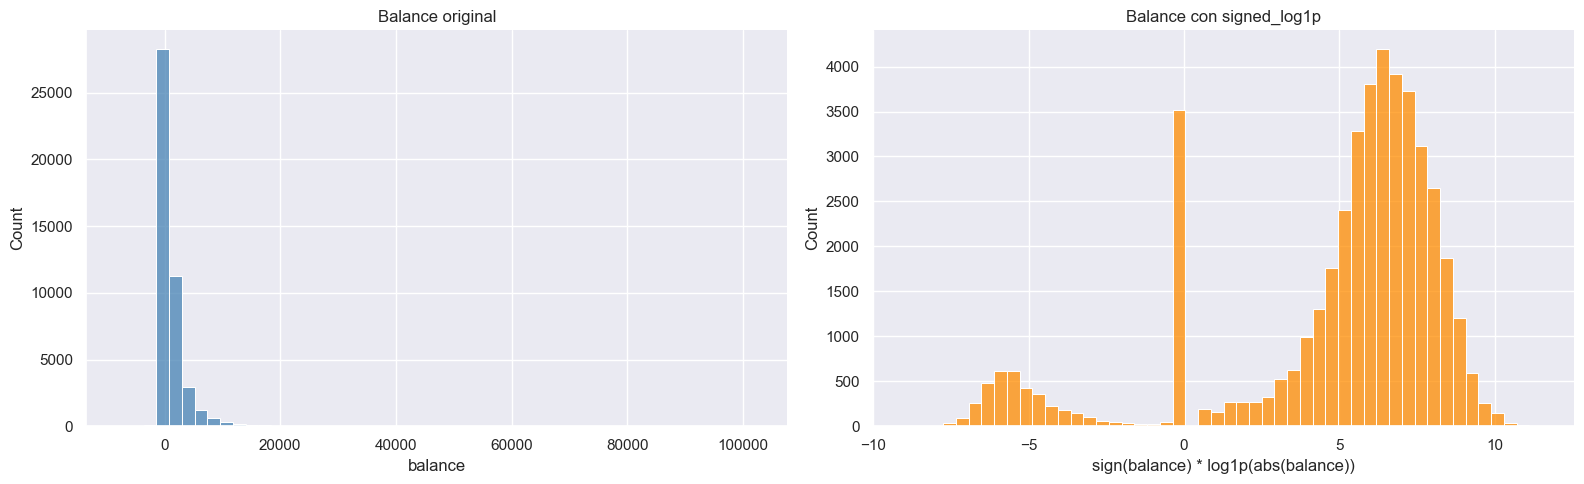

In [11]:
balance_signed_log = np.sign(df["balance"]) * np.log1p(np.abs(df["balance"]))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(df["balance"], bins=50, ax=axes[0], color="steelblue")
axes[0].set_title("Balance original")
axes[0].set_xlabel("balance")

sns.histplot(balance_signed_log, bins=50, ax=axes[1], color="darkorange")
axes[1].set_title("Balance con signed_log1p")
axes[1].set_xlabel("sign(balance) * log1p(abs(balance))")

plt.tight_layout()
plt.show()


In [12]:
zero_balance_summary = pd.DataFrame({
    "metric": [
        "exact_zero_count",
        "exact_zero_pct",
        "between_-50_and_50_count",
        "between_-50_and_50_pct"
    ],
    "value": [
        (df["balance"] == 0).sum(),
        (df["balance"] == 0).mean() * 100,
        df["balance"].between(-50, 50).sum(),
        df["balance"].between(-50, 50).mean() * 100
    ]
})

print_section("CONCENTRACION DE BALANCE CERCA DE 0")
display(zero_balance_summary)



                          CONCENTRACION DE BALANCE CERCA DE 0                           


,metric,value
0,exact_zero_count,"3,514.000"
1,exact_zero_pct,7.772
2,between_-50_and_50_count,"7,216.000"
3,between_-50_and_50_pct,15.961


Si la proporción de `balance = 0` es alta, entonces existe una acumulación real en ese punto. Si en cambio la proporción exacta en cero es menor, pero el porcentaje dentro del rango `[-50, 50]` es elevado, la concentración visual alrededor de `0` se explica mejor por la presencia de muchos saldos pequeños. Esta verificación ayuda a interpretar mejor la forma de la variable y a decidir si conviene aplicar transformaciones o escalados más robustos.


### 5.4.2. Tratamiento propuesto para `pdays=-1`

El valor `-1` en `pdays` no representa una cantidad temporal real, sino un código sentinela que indica que el cliente no había sido contactado previamente. Por esta razón, mantenerlo como si fuera un valor numérico ordinario introduciría una ambigüedad importante en el análisis y en el modelado, ya que el algoritmo podría interpretarlo como una distancia válida dentro de la escala de días.

Desde el punto de vista metodológico, reemplazar `-1` por `NaN` ofrece un beneficio claro: permite que el pipeline trate estos casos como ausencia de información temporal real, en lugar de forzar una interpretación numérica incorrecta. Esto evita que el modelo asuma relaciones artificiales entre `-1` y valores legítimos de `pdays`, como `1`, `5` o `30`, que sí representan días transcurridos desde un contacto previo.

Sin embargo, convertir `-1` en `NaN` no significa perder la señal contenida en esa condición. Para preservar esa información de negocio, se propone crear una variable binaria adicional, `was_previously_contacted`, que indique explícitamente si existió o no un contacto previo con el cliente. De esta forma, el problema original se descompone en dos señales más limpias y más interpretables:

- `was_previously_contacted`: captura la existencia de contacto previo.
- `pdays`: conserva únicamente la magnitud temporal cuando esa distancia realmente existe.

Esta estrategia aporta varias ventajas analíticas. En primer lugar, mejora la coherencia semántica de la variable, porque separa la ausencia de contacto de la noción de tiempo transcurrido. En segúndo lugar, facilita una imputación posterior más razonable dentro del pipeline numérico. Finalmente, reduce el riesgo de que modelos sensibles a magnitudes interpreten `-1` como un valor cercano a cero, cuando en realidad representa una condición cualitativamente distinta.


In [13]:
pdays_action = pd.DataFrame({
    "metric": [
        "rows_without_previous_contact",
        "rows_without_previous_contact_pct",
        "rows_with_previous_contact",
        "rows_with_previous_contact_pct"
    ],
    "value": [
        (df["pdays"] == -1).sum(),
        (df["pdays"] == -1).mean() * 100,
        (df["pdays"] != -1).sum(),
        (df["pdays"] != -1).mean() * 100
    ]
})

pdays_preview = df[["pdays", "previous"]].copy()
pdays_preview["was_previously_contacted"] = (pdays_preview["pdays"] != -1).astype(int)
pdays_preview["pdays_clean"] = pdays_preview["pdays"].replace(-1, np.nan)

print_section("REGLA PROPUESTA PARA PDAYS")
display(pdays_action)
display(pdays_preview.head(10))



                               REGLA PROPUESTA PARA PDAYS                               


,metric,value
0,rows_without_previous_contact,"36,954.000"
1,rows_without_previous_contact_pct,81.737
2,rows_with_previous_contact,"8,257.000"
3,rows_with_previous_contact_pct,18.263


,pdays,previous,was_previously_contacted,pdays_clean
0,-1,0,0,NaN
1,-1,0,0,NaN
2,-1,0,0,NaN
3,-1,0,0,NaN
4,-1,0,0,NaN
5,-1,0,0,NaN
6,-1,0,0,NaN
7,-1,0,0,NaN
8,-1,0,0,NaN
9,-1,0,0,NaN


### 5.4.3. Plan de imputación para faltantes reales

Como `ucimlrepo` entrega los faltantes como `NaN`, el notebook debe documentar una acción por columna. La regla base será conservar el faltante como categoría `missing` en variables categóricas, especialmente donde la ausencia de información puede tener significado operativo.


In [14]:
missing_action_plan = pd.DataFrame({
    "column": ["poutcome", "contact", "education", "job"],
    "missing_pct": [df[col].isna().mean() * 100 for col in ["poutcome", "contact", "education", "job"]],
    "proposed_action": [
        "imputar como categoría 'missing'; no eliminar por alta proporción",
        "imputar como categoría 'missing'; ausencia de canal puede ser informativa",
        "imputar como categoría 'missing' o moda en experimentos posteriores",
        "imputar como categoría 'missing' o moda en experimentos posteriores"
    ],
    "reason": [
        "faltante masivo asociado a no tener resultado de campaña previa",
        "faltante relevante asociado al tipo de contacto disponible",
        "faltante bajo; conservar registros evita pérdida innecesaria de datos",
        "faltante bajo; conservar registros evita pérdida innecesaria de datos"
    ]
})

print_section("PLAN DE IMPUTACIÓN")
display(missing_action_plan.sort_values("missing_pct", ascending=False))



                                   PLAN DE IMPUTACIÓN                                   


,column,missing_pct,proposed_action,reason
0,poutcome,81.748,imputar como categoría 'missing'; no eliminar ...,faltante masivo asociado a no tener resultado ...
1,contact,28.798,imputar como categoría 'missing'; ausencia de ...,faltante relevante asociado al tipo de contact...
2,education,4.107,imputar como categoría 'missing' o moda en exp...,faltante bajo; conservar registros evita pérdi...
3,job,0.637,imputar como categoría 'missing' o moda en exp...,faltante bajo; conservar registros evita pérdi...


### 5.4.4. Control explícito de leakage por `duration`

`duration` se puede analizar en EDA para entender el comportamiento histórico, pero debe excluirse antes del split y del pipeline final. Esta celda deja una lista inicial de columnas candidatas y una aserción que falla si `duration` se cuela accidentalmente.


In [15]:
TARGET_COL = "y"
LEAKAGE_COLS = ["duration"]

candidate_feature_cols = [col for col in df.columns if col not in [TARGET_COL] + LEAKAGE_COLS]

assert "duration" not in candidate_feature_cols, "duration no debe entrar al pipeline de modelado pre-llamada"

print(f"Columnas candidatas para modelado: {len(candidate_feature_cols)}")
print(candidate_feature_cols)


Columnas candidatas para modelado: 15
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day_of_week', 'month', 'campaign', 'pdays', 'previous', 'poutcome']


---
## 6. Pipeline de Preparación de Datos

En esta etapa los hallazgos de comprensión, auditoría y preparación se convierten en un flujo reproducible de preparación para modelado. La idea central es que las reglas de limpieza, ingeniería de variables, imputación, escalado y codificación vivan dentro de objetos de `scikit-learn`, de modo que el mismo proceso se aplique en entrenamiento, validación, prueba y predicción futura.

El pipeline cubre cuatro decisiones clave:

- Separar `X_raw` e `y` antes de cualquier ajuste estadístico.
- Excluir `duration` para evitar data leakage, porque solo se conoce durante o después de la llamada.
- Convertir `pdays=-1` en dos señales: `was_previously_contacted` y `pdays` como faltante imputable.
- Ajustar imputadores, escaladores y codificadores usando solamente `X_train`.


### 6.1. Importar componentes del pipeline

Se importan herramientas estándar de `scikit-learn` para expresar la preparación como pasos reutilizables. `FunctionTransformer` permite encapsular transformaciones propias del dominio, mientras que `ColumnTransformer` aplica tratamientos distintos a variables numéricas y categóricas dentro del mismo flujo.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

### 6.2. Separar datos crudos sin transformar

Primero se separa el target (`y`) de las variables predictoras en su forma cruda. El target se codifica como binario: `no -> 0` y `yes -> 1`. En este punto aún no se imputan faltantes, no se escalan variables y no se codifican categorías; esas operaciones se reservan para el pipeline y se ajustan después del split.

Mantener `X_raw` sin transformar ayuda a evitar fugas de información y deja claro que cualquier regla aprendida de los datos debe estimarse solo con el conjunto de entrenamiento.

In [17]:
TARGET_COL = "y"
LEAKAGE_COLS = ["duration"]
TEST_SIZE = 0.20

X_raw = df.drop(columns=[TARGET_COL]).copy()
y = df[TARGET_COL].map({"no": 0, "yes": 1})

print(f"Dimensión de X_raw: {X_raw.shape}")
print("Distribución del target codificado:")
display(y.value_counts(normalize=True).rename({0: "no", 1: "yes"}) * 100)

Dimensión de X_raw: (45211, 16)
Distribución del target codificado:


y
no    88.302
yes   11.698
Name: proportion, dtype: float64

### 6.3. Usar split estratificado

La revisión inicial mostró que la clase positiva (`yes`) es minoritaria. Por eso se usa `stratify=y`: mantiene aproximadamente la misma distribución de clases en train y test. También se fija `random_state=SEED` para que la partición sea reproducible.

El conjunto de prueba queda reservado desde este punto. El pipeline se ajustará con `X_train_raw` y después se aplicará a `X_test_raw`, sin recalcular imputaciones, escalas ni categorías sobre test.


In [18]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y
)

split_summary = pd.DataFrame({
    "n_rows": [len(X_train_raw), len(X_test_raw)],
    "positive_rate": [y_train.mean(), y_test.mean()]
}, index=["train", "test"])

print("Resumen del split estratificado:")
display(split_summary)

Resumen del split estratificado:


,n_rows,positive_rate
train,36168,0.117
test,9043,0.117


### 6.4. Feature Engineering: reglas de preparación del dominio

Esta función concentra reglas determinísticas que deben repetirse igual en entrenamiento y predicción:

- Elimina `duration` para evitar leakage.
- Crea `was_previously_contacted` a partir de `pdays`.
- Reemplaza `pdays=-1` por `NaN`, porque `-1` significa ausencia de contacto previo y no un número real de días.

Como estas reglas son fila a fila y no aprenden parámetros estadísticos, pueden ejecutarse antes del `ColumnTransformer` dentro del mismo `Pipeline`.


In [19]:
def add_domain_features(X: pd.DataFrame) -> pd.DataFrame:
    """Aplica reglas de preparación propias del problema sin ajustar parámetros."""
    X_prepared = X.drop(columns=LEAKAGE_COLS, errors="ignore").copy()

    X_prepared["was_previously_contacted"] = (X_prepared["pdays"] != -1).astype(int)
    X_prepared["pdays"] = X_prepared["pdays"].replace(-1, np.nan)

    return X_prepared


domain_feature_pipeline = FunctionTransformer(add_domain_features, validate=False)

X_train_domain = add_domain_features(X_train_raw)
numeric_features = X_train_domain.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train_domain.select_dtypes(include=["object", "string"]).columns.tolist()

print_section("FEATURES PARA PREPROCESAMIENTO")
print(f"Columnas excluidas por leakage: {LEAKAGE_COLS}")
print(f"Numéricas ({len(numeric_features)}): {numeric_features}")
print(f"Categóricas ({len(categorical_features)}): {categorical_features}")


                             FEATURES PARA PREPROCESAMIENTO                             
Columnas excluidas por leakage: ['duration']
Numéricas (7): ['age', 'balance', 'day_of_week', 'campaign', 'pdays', 'previous', 'was_previously_contacted']
Categóricas (9): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


### 6.5. Definir el `ColumnTransformer`

El `ColumnTransformer` junta dos pipelines:

- **Numérico**: `SimpleImputer(strategy="median")` rellena faltantes usando la mediana aprendida en entrenamiento, una opción robusta frente a outliers como los observados en `balance`, `campaign`, `pdays` y `previous`. Luego `StandardScaler` centra y escala variables numéricas para modelos sensibles a magnitudes.
- **Categórico**: `SimpleImputer(strategy="constant", fill_value="missing")` conserva faltantes como categoría explícita, útil en columnas como `poutcome` y `contact`. Después `OneHotEncoder(handle_unknown="ignore")` convierte categorías en columnas binarias y evita errores si en test aparece una categoría no vista en train.

Se usa `remainder="drop"` para que solo pasen columnas declaradas explícitamente. Esto reduce el riesgo de colar variables no revisadas.

In [20]:
try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("encoder", one_hot_encoder)
])

column_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

column_preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'balance', 'day_of_week', 'campaign',
                                  'pdays', 'previous',
                                  'was_previously_contacted']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='missing',
                                                                strategy='constant')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['job', 'marital', 'education', 'default',
                                  'housing', 'loan', 'contact', 'month',
                                  'poutcome'])],
                  verbose_feature_names_out=False)

### 6.6. Construir y ejecutar el pipeline completo de preparación

El pipeline final encadena la preparación de dominio con el `ColumnTransformer`. Al ejecutar `fit_transform(X_train_raw)`, el pipeline aprende medianas, escalas y categorías exclusivamente del entrenamiento. Con `transform(X_test_raw)`, aplica esas mismas reglas sobre test sin volver a ajustar nada.

La salida son matrices numéricas listas para modelos: `X_train_prepared` y `X_test_prepared`. También se extraen `feature_names` desde el paso `column_preprocessor` para interpretar las columnas resultantes del encoding.


In [21]:
data_preparation_pipeline = Pipeline(steps=[
    ("domain_features", domain_feature_pipeline),
    ("column_preprocessor", column_preprocessor)
])

X_train_prepared = data_preparation_pipeline.fit_transform(X_train_raw)
X_test_prepared = data_preparation_pipeline.transform(X_test_raw)

feature_names = data_preparation_pipeline.named_steps["column_preprocessor"].get_feature_names_out()

print(f"X_train_prepared: {X_train_prepared.shape}")
print(f"X_test_prepared:  {X_test_prepared.shape}")
print(f"Número final de variables después del encoding: {len(feature_names)}")
print("Primeras variables transformadas:")
display(pd.Series(feature_names).head(20))

data_preparation_pipeline

X_train_prepared: (36168, 51)
X_test_prepared:  (9043, 51)
Número final de variables después del encoding: 51
Primeras variables transformadas:


0                          age
1                      balance
2                  day_of_week
3                     campaign
4                        pdays
5                     previous
6     was_previously_contacted
7                   job_admin.
8              job_blue-collar
9             job_entrepreneur
10               job_housemaid
11              job_management
12                 job_missing
13                 job_retired
14           job_self-employed
15                job_services
16                 job_student
17              job_technician
18              job_unemployed
19            marital_divorced
dtype: object

Pipeline(steps=[('domain_features',
                 FunctionTransformer(func=<function add_domain_features at 0x0000026EA5C3A700>)),
                ('column_preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'balance',
                                                   'day_of_week', 'campaign',
                                                   'pdays', 'previous',
                                                   'was_previously_contacted']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'poutcome'])],
                                   verbose_feature_names_out=False))])

---
## 7. Modelo XGBoost

Se entrena un modelo `XGBClassifier` como estimador principal del notebook. XGBoost es una alternativa potente para datos tabulares porque construye árboles de manera secuencial, corrigiendo errores de iteraciones anteriores y capturando relaciones no lineales e interacciones entre variables.

Se mantiene el mismo patrón de trabajo: `data_preparation_pipeline` se conecta con el estimador dentro de un único `Pipeline`. Así se evita aplicar transformaciones manuales fuera del flujo de entrenamiento y se reduce el riesgo de inconsistencias entre entrenamiento y predicción.

### 7.1. Ejecución completa de pipelines

Esta celda ejecuta el flujo end-to-end de modelado: valida los insumos, entrena el `Pipeline` completo, genera predicciones, calcula probabilidades, consolida métricas y confirma que la variable `duration` no aparezca en las variables finales del modelo.

El objetivo es que el entrenamiento y la predicción usen exactamente el mismo flujo reproducible: preparación de dominio, imputación, escalado, One-Hot Encoding y `XGBClassifier`.


                            EJECUCIÓN COMPLETA DE PIPELINES                             


,check,value
0,train rows,36168
1,test rows,9043
2,final features,51
3,scale_pos_weight,7.548
4,duration excluded,OK
5,pipeline fitted,OK



                                   RESULTADOS XGBOOST                                   


,metric,value
0,precisión,0.345
1,recall,0.648
2,f1,0.451
3,roc_auc,0.805
4,pr_auc,0.467


Reporte de Clasificación:
              precisión    recall  f1-score   support

      no (0)       0.95      0.84      0.89      7985
     yes (1)       0.35      0.65      0.45      1058

    accuracy                           0.82      9043
   macro avg       0.65      0.74      0.67      9043
weighted avg       0.88      0.82      0.84      9043



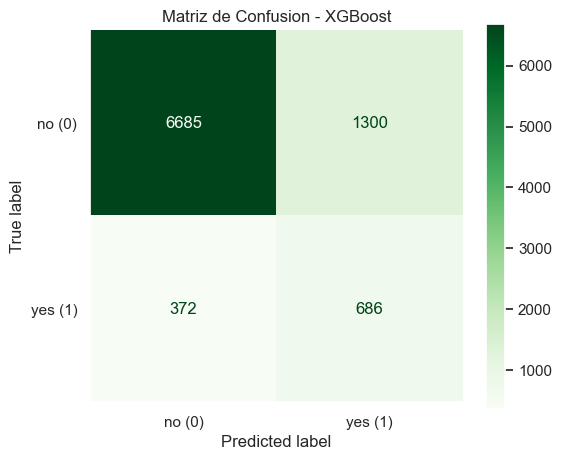

In [22]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

required_pipeline_objects = [
    "X_train_raw", "X_test_raw", "y_train", "y_test",
    "data_preparation_pipeline", "SEED"
]
missing_pipeline_objects = [name for name in required_pipeline_objects if name not in globals()]
assert not missing_pipeline_objects, f"Faltan objetos para ejecutar el pipeline completo: {missing_pipeline_objects}"

negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())
scale_pos_weight = negative_count / positive_count

xgb_pipeline = Pipeline(steps=[
    ("preparation", data_preparation_pipeline),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="binary:logistic",
        eval_metric="aucpr",
        scale_pos_weight=scale_pos_weight,
        random_state=SEED,
        n_jobs=-1,
        tree_method="hist"
    ))
])

xgb_pipeline.fit(X_train_raw, y_train)

y_pred_xgb = xgb_pipeline.predict(X_test_raw)
y_proba_xgb = xgb_pipeline.predict_proba(X_test_raw)[:, 1]

xgb_feature_names = xgb_pipeline.named_steps["preparation"].named_steps["column_preprocessor"].get_feature_names_out()

assert len(y_pred_xgb) == len(y_test), "Las predicciones deben tener la misma longitud que y_test."
assert len(y_proba_xgb) == len(y_test), "Las probabilidades deben tener la misma longitud que y_test."
assert "duration" not in set(xgb_feature_names), "duration no debe aparecer en las variables finales por riesgo de leakage."

xgb_metrics = pd.DataFrame({
    "metric": ["precisión", "recall", "f1", "roc_auc", "pr_auc"],
    "value": [
        precision_score(y_test, y_pred_xgb, zero_division=0),
        recall_score(y_test, y_pred_xgb, zero_division=0),
        f1_score(y_test, y_pred_xgb, zero_division=0),
        roc_auc_score(y_test, y_proba_xgb),
        average_precision_score(y_test, y_proba_xgb)
    ]
})

pipeline_execution_summary = pd.DataFrame({
    "check": [
        "train rows",
        "test rows",
        "final features",
        "scale_pos_weight",
        "duration excluded",
        "pipeline fitted"
    ],
    "value": [
        len(X_train_raw),
        len(X_test_raw),
        len(xgb_feature_names),
        scale_pos_weight,
        "OK",
        "OK"
    ]
})

print_section("EJECUCIÓN COMPLETA DE PIPELINES")
display(pipeline_execution_summary)

print_section("RESULTADOS XGBOOST")
display(xgb_metrics)

print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred_xgb, labels=[0, 1], target_names=["no (0)", "yes (1)"], zero_division=0))

cm_xgb = confusion_matrix(y_test, y_pred_xgb, labels=[0, 1])
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=["no (0)", "yes (1)"])

fig, ax = plt.subplots(figsize=(6, 5))
disp_xgb.plot(cmap="Greens", values_format="d", ax=ax)
ax.grid(False)
plt.title("Matriz de Confusión - XGBoost")
plt.show()

### 7.2. Ajuste del umbral de decisión

El umbral estándar de `0.50` no siempre es el más adecuado cuando la clase positiva es minoritaria. En este bloque se evalúan múltiples umbrales usando las probabilidades `y_proba_xgb` y se selecciona el umbral que maximiza el F1-score de la clase positiva.

Este criterio busca equilibrar dos objetivos: capturar clientes que sí aceptarían el depósito (`recall`) y evitar demasiados contactos poco prometedores (`precisión`).


                              AJUSTE DEL UMBRAL - XGBOOST                               
Mejor umbral según F1 de la clase positiva: 0.65


,threshold,contact_rate,precisión,recall,f1
12,0.650,0.123,0.488,0.512,0.500
11,0.600,0.147,0.442,0.553,0.491
13,0.700,0.105,0.519,0.463,0.489
10,0.550,0.176,0.401,0.602,0.481
14,0.750,0.088,0.541,0.408,0.466
9,0.500,0.220,0.345,0.648,0.451
15,0.800,0.068,0.570,0.331,0.419
8,0.450,0.283,0.292,0.705,0.413
16,0.850,0.049,0.655,0.273,0.386
7,0.400,0.359,0.246,0.756,0.372


,metric,value
0,threshold,0.650
1,contact_rate,0.123
2,precisión,0.488
3,recall,0.512
4,f1,0.500


Reporte de Clasificación con umbral ajustado:
              precisión    recall  f1-score   support

      no (0)       0.93      0.93      0.93      7985
     yes (1)       0.49      0.51      0.50      1058

    accuracy                           0.88      9043
   macro avg       0.71      0.72      0.72      9043
weighted avg       0.88      0.88      0.88      9043



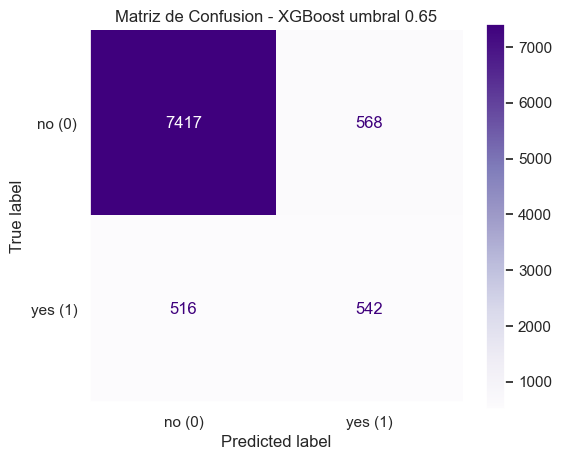

In [23]:
threshold_grid = np.arange(0.05, 0.96, 0.05)
threshold_results = []

for threshold in threshold_grid:
    y_pred_threshold = (y_proba_xgb >= threshold).astype(int)
    threshold_results.append({
        "threshold": threshold,
        "contact_rate": y_pred_threshold.mean(),
        "precisión": precision_score(y_test, y_pred_threshold, zero_division=0),
        "recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "f1": f1_score(y_test, y_pred_threshold, zero_division=0)
    })

threshold_results = pd.DataFrame(threshold_results)
best_threshold_row = threshold_results.sort_values(
    ["f1", "recall", "precisión"],
    ascending=False
).iloc[0]

BEST_THRESHOLD = float(best_threshold_row["threshold"])
y_pred_xgb_adjusted = (y_proba_xgb >= BEST_THRESHOLD).astype(int)

adjusted_metrics = pd.DataFrame({
    "metric": ["threshold", "contact_rate", "precisión", "recall", "f1"],
    "value": [
        BEST_THRESHOLD,
        y_pred_xgb_adjusted.mean(),
        precision_score(y_test, y_pred_xgb_adjusted, zero_division=0),
        recall_score(y_test, y_pred_xgb_adjusted, zero_division=0),
        f1_score(y_test, y_pred_xgb_adjusted, zero_division=0)
    ]
})

print_section("AJUSTE DEL UMBRAL - XGBOOST")
print(f"Mejor umbral según F1 de la clase positiva: {BEST_THRESHOLD:.2f}")
display(threshold_results.sort_values("f1", ascending=False).head(10))

display(adjusted_metrics)

print("Reporte de Clasificación con umbral ajustado:")
print(classification_report(y_test, y_pred_xgb_adjusted, labels=[0, 1], target_names=["no (0)", "yes (1)"], zero_division=0))

cm_xgb_adjusted = confusion_matrix(y_test, y_pred_xgb_adjusted, labels=[0, 1])
disp_xgb_adjusted = ConfusionMatrixDisplay(confusion_matrix=cm_xgb_adjusted, display_labels=["no (0)", "yes (1)"])

fig, ax = plt.subplots(figsize=(6, 5))
disp_xgb_adjusted.plot(cmap="Purples", values_format="d", ax=ax)
ax.grid(False)
plt.title(f"Matriz de Confusión - XGBoost umbral {BEST_THRESHOLD:.2f}")
plt.show()

### 7.3. Evaluación del modelo

La evaluación del modelo se concentra en la clase positiva (`yes`), porque el objetivo de negocio no es clasificar correctamente a la mayoría que no acepta, sino priorizar clientes con mayor probabilidad de aceptar el depósito. Por esa razón, las métricas más relevantes son `precisión`, `recall`, `F1` y `PR-AUC`, complementadas con la matriz de confusión.

`XGBClassifier` es una opción sólida para este problema porque entrena árboles de forma secuencial, optimiza una función objetivo explícita y puede capturar relaciones no lineales e interacciones entre variables demográficas, financieras y de campaña. Además, permite usar `scale_pos_weight` para compensar el desbalance de clases y estimar importancia de variables para interpretar qué señales impulsan la predicción.

En este notebook se usa como modelo principal porque se adapta bien a datos tabulares mixtos después del `ColumnTransformer`, maneja estructuras complejas y permite ajustar el umbral de decisión con `y_proba_xgb` para alinear el desempeño técnico con el costo operativo de contactar clientes.

In [24]:
standard_threshold_metrics = pd.DataFrame({
    "threshold_type": ["standard_0.50"],
    "threshold": [0.50],
    "contact_rate": [pd.Series(y_pred_xgb).mean()],
    "precisión": [precision_score(y_test, y_pred_xgb, zero_division=0)],
    "recall": [recall_score(y_test, y_pred_xgb, zero_division=0)],
    "f1": [f1_score(y_test, y_pred_xgb, zero_division=0)],
    "roc_auc": [roc_auc_score(y_test, y_proba_xgb)],
    "pr_auc": [average_precision_score(y_test, y_proba_xgb)]
})

adjusted_threshold_metrics = pd.DataFrame({
    "threshold_type": ["adjusted_f1"],
    "threshold": [BEST_THRESHOLD],
    "contact_rate": [pd.Series(y_pred_xgb_adjusted).mean()],
    "precisión": [precision_score(y_test, y_pred_xgb_adjusted, zero_division=0)],
    "recall": [recall_score(y_test, y_pred_xgb_adjusted, zero_division=0)],
    "f1": [f1_score(y_test, y_pred_xgb_adjusted, zero_division=0)],
    "roc_auc": [roc_auc_score(y_test, y_proba_xgb)],
    "pr_auc": [average_precision_score(y_test, y_proba_xgb)]
})

model_evaluation_summary = pd.concat(
    [standard_threshold_metrics, adjusted_threshold_metrics],
    ignore_index=True
)

model_fit_rationale = pd.DataFrame({
    "criterio": [
        "Datos tabulares mixtos",
        "Relaciones no lineales",
        "Interacciones entre variables",
        "Desbalance de clases",
        "Interpretabilidad operativa",
        "Control de decisión de negocio"
    ],
    "por_qué_importa": [
        "El dataset combina variables numéricas y categóricas procesadas por el pipeline.",
        "La aceptación de un depósito puede depender de patrones que no son lineales.",
        "El boosting puede capturar combinaciones entre perfil financiero, historial y campaña.",
        "scale_pos_weight compensa la menor frecuencia de clientes que aceptan el depósito.",
        "La importancia de variables ayuda a explicar las señales más influyentes.",
        "El umbral ajustado traduce probabilidades en una política de contacto más útil."
    ]
})

print_section("EVALUACIÓN DEL MODELO")
display(model_evaluation_summary)

print_section("POR QUÉ XGBOOST ES ADECUADO PARA ESTE PROBLEMA")
display(model_fit_rationale)


                                 EVALUACIÓN DEL MODELO                                  


,threshold_type,threshold,contact_rate,precisión,recall,f1,roc_auc,pr_auc
0,standard_0.50,0.500,0.220,0.345,0.648,0.451,0.805,0.467
1,adjusted_f1,0.650,0.123,0.488,0.512,0.500,0.805,0.467



                     POR QUÉ XGBOOST ES ADECUADO PARA ESTE PROBLEMA                     


,criterio,por_qué_importa
0,Datos tabulares mixtos,El dataset combina variables numéricas y categ...
1,Relaciones no lineales,La aceptación de un depósito puede depender de...
2,Interacciones entre variables,El boosting puede capturar combinaciones entre...
3,Desbalance de clases,scale_pos_weight compensa la menor frecuencia ...
4,Interpretabilidad operativa,La importancia de variables ayuda a explicar l...
5,Control de decisión de negocio,El umbral ajustado traduce probabilidades en u...


### 7.4. Importancia de variables

La importancia de variables de XGBoost permite identificar qué señales tuvieron mayor peso relativo dentro del modelo. Como el pipeline usa One-Hot Encoding, las variables categóricas aparecen desagregadas por categoría.

Esta lectura debe considerarse exploratoria: para una interpretación más robusta se recomienda complementar con permutation importance o SHAP, especialmente si se desea justificar decisiones comerciales.


                               TOP 20 VARIABLES - XGBOOST                               


,feature,importance
0,poutcome_success,0.263
1,contact_missing,0.090
2,housing_yes,0.046
3,month_mar,0.038
4,housing_no,0.037
5,contact_cellular,0.031
6,month_oct,0.030
7,marital_married,0.028
8,month_jun,0.027
9,loan_yes,0.027


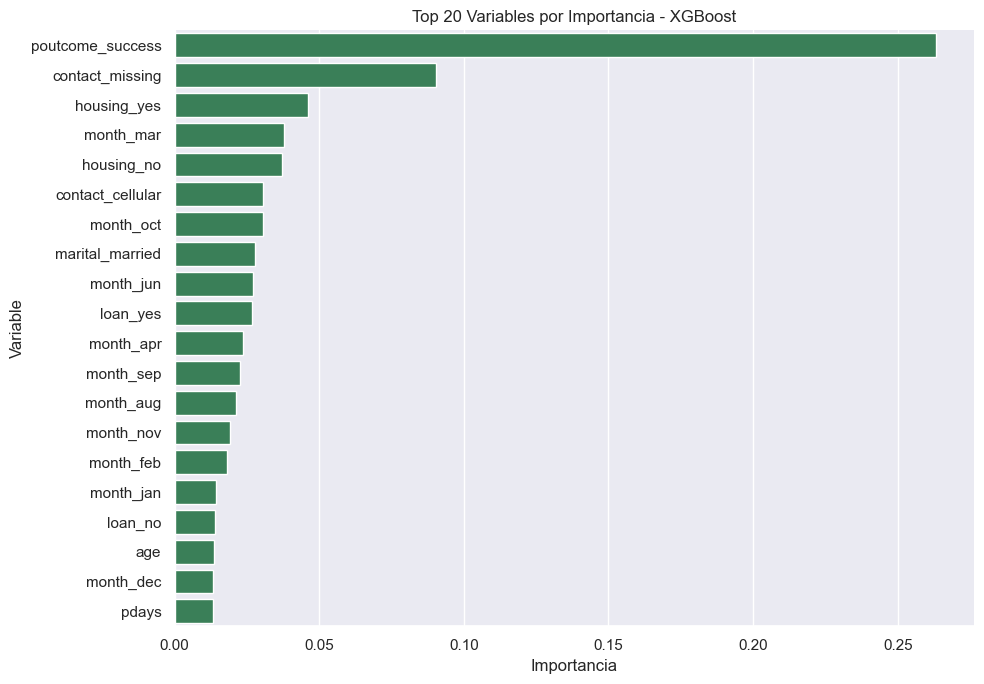

In [25]:
xgb_feature_names = xgb_pipeline.named_steps["preparation"].named_steps["column_preprocessor"].get_feature_names_out()
xgb_importances = xgb_pipeline.named_steps["model"].feature_importances_

feature_importance_xgb = (
    pd.DataFrame({
        "feature": xgb_feature_names,
        "importance": xgb_importances
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print_section("TOP 20 VARIABLES - XGBOOST")
display(feature_importance_xgb.head(20))

plt.figure(figsize=(10, 7))
sns.barplot(
    data=feature_importance_xgb.head(20),
    x="importance",
    y="feature",
    color="seagreen"
)
plt.title("Top 20 Variables por Importancia - XGBoost")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

### 7.5. Lectura inicial del modelo

El `XGBClassifier` debe evaluarse usando especialmente métricas de la clase positiva (`yes`). En este problema, el foco no consiste solo en aumentar el accuracy, sino en elevar la capacidad de encontrar clientes propensos a aceptar el depósito manteniendo una precisión operativamente razonable.

El umbral ajustado `BEST_THRESHOLD` permite convertir las probabilidades `y_proba_xgb` en decisiones de contacto más alineadas con el balance entre cobertura de clientes potenciales y costo operativo de la campaña.

### 7.6. Impacto de las Técnicas Aplicadas

Este bloque resume el efecto esperado y medible de las técnicas aplicadas sobre `XGBClassifier`: optimización del umbral de decisión y ponderación de clases mediante `scale_pos_weight`. Ambas técnicas son relevantes porque el problema presenta desbalanceo entre clientes que aceptan (`yes`) y clientes que no aceptan (`no`) el depósito.

#### Threshold Optimization

La optimización del threshold reemplaza el umbral default de `0.50` por `BEST_THRESHOLD`, seleccionado según el mejor balance de F1 para la clase positiva (`yes`).

**Efecto esperado:**

- Al aumentar el threshold, el modelo exige mayor confianza para predecir `yes`.
- Esto reduce contactos de baja probabilidad y mejora la precisión de la campaña.
- Al disminuir el threshold, el modelo captura más clientes potenciales, pero puede aumentar los falsos positivos.
- El trade-off principal está entre contactar más clientes propensos a aceptar y controlar el costo operativo de la campaña.

#### Ponderación de clases con `scale_pos_weight`

El modelo usa `scale_pos_weight` dentro de `XGBClassifier`. Esta técnica aumenta el peso relativo de la clase positiva durante el entrenamiento para reducir el sesgo hacia la clase mayoritaria (`no`).

Sin ponderación de clases, un modelo puede obtener un accuracy aparentemente alto clasificando demasiados registros como `no`, pero fallar en el objetivo de negocio: identificar clientes con mayor probabilidad de aceptar (`yes`). Por eso, para este caso son más importantes métricas como `recall`, `precisión`, `F1` y `PR-AUC` sobre la clase positiva.

**Resultado esperado:**

- Mayor capacidad para detectar clientes `yes` frente a un modelo sin ponderación.
- Mejor F1-macro cuando el modelo logra equilibrar el desempeño entre clases.
- Menor riesgo de seleccionar un modelo con buen accuracy, pero poco útil para una campaña comercial.

In [26]:
from sklearn.base import clone

# Comparación 1: impacto del umbral ajustado frente al umbral default de 0.50.
y_pred_default_threshold = (y_proba_xgb >= 0.50).astype(int)
y_pred_best_threshold = (y_proba_xgb >= BEST_THRESHOLD).astype(int)

impacto_threshold = pd.DataFrame([
    {
        "escenario": "Threshold default 0.50",
        "threshold": 0.50,
        "precision_yes": precision_score(y_test, y_pred_default_threshold, zero_division=0),
        "recall_yes": recall_score(y_test, y_pred_default_threshold, zero_division=0),
        "f1_yes": f1_score(y_test, y_pred_default_threshold, zero_division=0),
        "contact_rate": y_pred_default_threshold.mean()
    },
    {
        "escenario": "Threshold optimizado",
        "threshold": BEST_THRESHOLD,
        "precision_yes": precision_score(y_test, y_pred_best_threshold, zero_division=0),
        "recall_yes": recall_score(y_test, y_pred_best_threshold, zero_division=0),
        "f1_yes": f1_score(y_test, y_pred_best_threshold, zero_division=0),
        "contact_rate": y_pred_best_threshold.mean()
    }
])

display(impacto_threshold.style.format({
    "threshold": "{:.2f}",
    "precision_yes": "{:.2%}",
    "recall_yes": "{:.2%}",
    "f1_yes": "{:.2%}",
    "contact_rate": "{:.2%}"
}))

# Comparación 2: impacto de scale_pos_weight frente a un XGBoost sin ponderación.
xgb_pipeline_sin_ponderacion = Pipeline([
    ("preparation", clone(data_preparation_pipeline)),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="binary:logistic",
        eval_metric="aucpr",
        scale_pos_weight=1,
        random_state=SEED,
        n_jobs=-1,
        tree_method="hist"
    ))
])

xgb_pipeline_sin_ponderacion.fit(X_train_raw, y_train)
y_proba_sin_ponderacion = xgb_pipeline_sin_ponderacion.predict_proba(X_test_raw)[:, 1]
y_pred_sin_ponderacion = (y_proba_sin_ponderacion >= 0.50).astype(int)

impacto_ponderacion = pd.DataFrame([
    {
        "modelo": "XGBoost sin scale_pos_weight",
        "threshold": 0.50,
        "precision_yes": precision_score(y_test, y_pred_sin_ponderacion, zero_division=0),
        "recall_yes": recall_score(y_test, y_pred_sin_ponderacion, zero_division=0),
        "f1_yes": f1_score(y_test, y_pred_sin_ponderacion, zero_division=0),
        "f1_macro": f1_score(y_test, y_pred_sin_ponderacion, average="macro", zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba_sin_ponderacion),
        "pr_auc": average_precision_score(y_test, y_proba_sin_ponderacion)
    },
    {
        "modelo": "XGBoost con scale_pos_weight",
        "threshold": BEST_THRESHOLD,
        "precision_yes": precision_score(y_test, y_pred_best_threshold, zero_division=0),
        "recall_yes": recall_score(y_test, y_pred_best_threshold, zero_division=0),
        "f1_yes": f1_score(y_test, y_pred_best_threshold, zero_division=0),
        "f1_macro": f1_score(y_test, y_pred_best_threshold, average="macro", zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba_xgb),
        "pr_auc": average_precision_score(y_test, y_proba_xgb)
    }
])

display(impacto_ponderacion.style.format({
    "threshold": "{:.2f}",
    "precision_yes": "{:.2%}",
    "recall_yes": "{:.2%}",
    "f1_yes": "{:.2%}",
    "f1_macro": "{:.2%}",
    "roc_auc": "{:.2%}",
    "pr_auc": "{:.2%}"
}))

,escenario,threshold,precision_yes,recall_yes,f1_yes,contact_rate
0,Threshold default 0.50,0.50,34.54%,64.84%,45.07%,21.96%
1,Threshold optimizado,0.65,48.83%,51.23%,50.00%,12.27%


,modelo,threshold,precision_yes,recall_yes,f1_yes,f1_macro,roc_auc,pr_auc
0,XGBoost sin scale_pos_weight,0.50,65.78%,23.25%,34.36%,64.36%,80.89%,47.16%
1,XGBoost con scale_pos_weight,0.65,48.83%,51.23%,50.00%,71.60%,80.53%,46.71%


### 7.7. Evaluación del Negocio

#### ¿El modelo es útil?

**Sí, con consideraciones.**

El modelo es útil para priorizar clientes con mayor probabilidad de aceptar un depósito, siempre que se use como una herramienta de apoyo para la campaña comercial y no como una decisión automática aislada. Su valor principal está en ordenar prospectos, reducir contactos poco prometedores y enfocar el esfuerzo del equipo comercial.

#### Fortalezas

- **Priorización comercial:** si el modelo predice `yes`, el cliente tiene mayor probabilidad estimada de aceptar que un cliente seleccionado aleatoriamente.
- **Control del costo operativo:** el umbral ajustado permite regular cuántos clientes se contactan y evita depender del threshold default de `0.50`.
- **Manejo del desbalanceo:** `scale_pos_weight` reduce el sesgo hacia la clase mayoritaria (`no`).
- **Aprendizaje secuencial:** XGBoost ajusta árboles de forma iterativa, corrigiendo errores de modelos anteriores.

#### Limitaciones

- **Sensibilidad limitada en `yes`:** si el recall de la clase positiva es bajo, el modelo puede dejar por fuera clientes que sí habrían aceptado el depósito.
- **Trade-off entre precisión y recall:** aumentar la precisión reduce contactos innecesarios, pero puede disminuir la cobertura de clientes potenciales.
- **Uso dependiente del umbral:** el desempeño operativo cambia según el threshold seleccionado, por lo que debe revisarse con objetivos de negocio.
- **No reemplaza validación productiva:** antes de producción se recomienda validar estabilidad temporal, monitoreo de datos y costos reales de contacto.

In [27]:
business_eval = pd.DataFrame([
    {
        "aspecto": "Precisión en clientes yes",
        "valor": precision_score(y_test, y_pred_xgb_adjusted, zero_division=0),
        "lectura_negocio": "Confiabilidad de los clientes priorizados para contacto."
    },
    {
        "aspecto": "Recall en clientes yes",
        "valor": recall_score(y_test, y_pred_xgb_adjusted, zero_division=0),
        "lectura_negocio": "Cobertura de clientes que realmente aceptaráan el depósito."
    },
    {
        "aspecto": "F1 en clientes yes",
        "valor": f1_score(y_test, y_pred_xgb_adjusted, zero_division=0),
        "lectura_negocio": "Balance entre precisión comercial y cobertura de oportunidades."
    },
    {
        "aspecto": "Tasa de contacto sugerida",
        "valor": y_pred_xgb_adjusted.mean(),
        "lectura_negocio": "Porcentaje de clientes que el modelo recomendaría contactar."
    },
    {
        "aspecto": "Brecha de generalización F1",
        "valor": abs(
            f1_score(y_train, (xgb_pipeline.predict_proba(X_train_raw)[:, 1] >= BEST_THRESHOLD).astype(int), zero_division=0) -
            f1_score(y_test, y_pred_xgb_adjusted, zero_division=0)
        ),
        "lectura_negocio": "Diferencia entre desempeño en entrenamiento y test usando el mismo threshold."
    }
])

display(business_eval.style.format({"valor": "{:.2%}"}))

precision_yes = precision_score(y_test, y_pred_xgb_adjusted, zero_division=0)
recall_yes = recall_score(y_test, y_pred_xgb_adjusted, zero_division=0)
f1_yes = f1_score(y_test, y_pred_xgb_adjusted, zero_division=0)
contact_rate = y_pred_xgb_adjusted.mean()

def business_verdict(precision_yes, recall_yes, f1_yes):
    if f1_yes >= 0.60 and precision_yes >= 0.50:
        return "Sí, con consideraciones: el modelo es útil para priorización comercial."
    if recall_yes >= 0.50 or precision_yes >= 0.50:
        return "PARCIALMENTE: el modelo aporta señal, pero requiere ajuste antes de producción."
    return "NO AÚN: el desempeño actual no es suficiente para una decisión productiva."

print(business_verdict(precision_yes, recall_yes, f1_yes))
print(f"Precisión yes: {precision_yes:.2%}")
print(f"Recall yes: {recall_yes:.2%}")
print(f"F1 yes: {f1_yes:.2%}")
print(f"Tasa de contacto sugerida: {contact_rate:.2%}")

,aspecto,valor,lectura_negocio
0,Precisión en clientes yes,48.83%,Confiabilidad de los clientes priorizados para contacto.
1,Recall en clientes yes,51.23%,Cobertura de clientes que realmente aceptaráan el depósito.
2,F1 en clientes yes,50.00%,Balance entre precisión comercial y cobertura de oportunidades.
3,Tasa de contacto sugerida,12.27%,Porcentaje de clientes que el modelo recomendaría contactar.
4,Brecha de generalización F1,2.29%,Diferencia entre desempeño en entrenamiento y test usando el mismo threshold.


PARCIALMENTE: el modelo aporta señal, pero requiere ajuste antes de producción.
Precisión yes: 48.83%
Recall yes: 51.23%
F1 yes: 50.00%
Tasa de contacto sugerida: 12.27%


### 7.8. Conclusiones y Recomendaciones

#### Logros Principales

- **Manejo del desbalanceo:** el uso de `scale_pos_weight` permite que `XGBClassifier` no se incline exclusivamente hacia la clase mayoritaria (`no`) y mantenga foco en la clase de interés (`yes`).
- **Threshold optimization efectivo:** el umbral `BEST_THRESHOLD` ajusta la decisión del modelo al objetivo de negocio, controlando el balance entre cobertura de clientes potenciales y costo de contacto.
- **Pipeline reproducible:** el flujo con preparación de datos, Feature Engineering, codificación, escalado y `XGBClassifier` deja una base consistente para evaluación y mejora continua.
- **Modelo tabular avanzado:** XGBoost es apropiado para capturar relaciones no lineales e interacciones relevantes en campañas comerciales.

#### Áreas de Mejora Futura

**Validación y selección de umbral:**

- Separar entrenamiento, validación y test para elegir `BEST_THRESHOLD` sin usar el conjunto de prueba.
- Evaluar validación cruzada estratificada para medir estabilidad.
- Definir el umbral final con costos reales de contacto y valor esperado de conversión.

**Ajuste de hiperparámetros:**

- Optimizar `max_depth`, `learning_rate`, `n_estimators`, `subsample`, `colsample_bytree`, `min_child_weight` y regularización.
- Probar early stopping con un conjunto de validación.
- Comparar contra Logistic Regression, árboles de decisión y otros modelos base.

**Calibración e interpretación:**

- Aplicar Platt Scaling o Isotonic Regression si se requieren probabilidades bien calibradas.
- Complementar la importancia de variables con permutation importance o SHAP.
- Revisar estabilidad de las variables más influyentes si cambia la población objetivo.

#### Decisión Final

El modelo `XGBClassifier` es **ACEPTADO como candidato funcional**, con las siguientes condiciones antes de una salida productiva formal:

- Usar el threshold optimizado `BEST_THRESHOLD` solo como referencia inicial; idealmente debe recalibrarse en validación.
- Implementarlo como pipeline de priorización inicial de clientes.
- Complementar con revisión humana o comercial en decisiones críticas.
- Monitorear continuamente `precisión`, `recall`, `F1`, `PR-AUC`, tasa de contacto y distribución de probabilidades.
- Establecer alertas si el recall de la clase `yes` cae por debajo del umbral mínimo definido por negocio.

In [28]:
conclusion_metrics = {
    "threshold_optimizado": BEST_THRESHOLD,
    "precision_yes": precision_score(y_test, y_pred_xgb_adjusted, zero_division=0),
    "recall_yes": recall_score(y_test, y_pred_xgb_adjusted, zero_division=0),
    "f1_yes": f1_score(y_test, y_pred_xgb_adjusted, zero_division=0),
    "f1_macro": f1_score(y_test, y_pred_xgb_adjusted, average="macro", zero_division=0),
    "accuracy": np.mean(y_test == y_pred_xgb_adjusted),
    "contact_rate": y_pred_xgb_adjusted.mean(),
    "pr_auc": average_precision_score(y_test, y_proba_xgb),
    "roc_auc": roc_auc_score(y_test, y_proba_xgb)
}

conclusion_summary = pd.DataFrame([
    {"indicador": "Threshold optimizado", "valor": conclusion_metrics["threshold_optimizado"], "lectura": "Umbral recomendado para convertir probabilidades en decisión de contacto."},
    {"indicador": "Precisión yes", "valor": conclusion_metrics["precision_yes"], "lectura": "Confiabilidad de los clientes priorizados como posibles aceptantes."},
    {"indicador": "Recall yes", "valor": conclusion_metrics["recall_yes"], "lectura": "Cobertura de clientes que realmente aceptan el depósito."},
    {"indicador": "F1 yes", "valor": conclusion_metrics["f1_yes"], "lectura": "Balance entre precisión y cobertura sobre la clase positiva."},
    {"indicador": "F1 macro", "valor": conclusion_metrics["f1_macro"], "lectura": "Balance general del desempeño entre clases."},
    {"indicador": "Accuracy", "valor": conclusion_metrics["accuracy"], "lectura": "Desempeño global usado solo como métrica complementaria."},
    {"indicador": "Tasa de contacto", "valor": conclusion_metrics["contact_rate"], "lectura": "Porcentaje de clientes que serían contactados por el modelo."},
    {"indicador": "PR-AUC", "valor": conclusion_metrics["pr_auc"], "lectura": "Calidad del ranking en un problema desbalanceado."},
    {"indicador": "ROC-AUC", "valor": conclusion_metrics["roc_auc"], "lectura": "Capacidad general de separación entre clases."}
])

display(conclusion_summary.style.format({"valor": "{:.2%}"}))

min_recall_yes = 0.45
min_f1_macro = 0.60

if conclusion_metrics["recall_yes"] >= min_recall_yes and conclusion_metrics["f1_macro"] >= min_f1_macro:
    decision_final = "ACEPTADO como candidato para producción controlada"
else:
    decision_final = "REQUIERE MEJORAS antes de producción"

print(f"Decisión final: {decision_final}")
print(f"Condición recall yes >= {min_recall_yes:.0%}: {conclusion_metrics['recall_yes']:.2%}")
print(f"Condición F1 macro >= {min_f1_macro:.0%}: {conclusion_metrics['f1_macro']:.2%}")
print(f"Threshold recomendado: {BEST_THRESHOLD:.2f}")

,indicador,valor,lectura
0,Threshold optimizado,65.00%,Umbral recomendado para convertir probabilidades en decisión de contacto.
1,Precisión yes,48.83%,Confiabilidad de los clientes priorizados como posibles aceptantes.
2,Recall yes,51.23%,Cobertura de clientes que realmente aceptan el depósito.
3,F1 yes,50.00%,Balance entre precisión y cobertura sobre la clase positiva.
4,F1 macro,71.60%,Balance general del desempeño entre clases.
5,Accuracy,88.01%,Desempeño global usado solo como métrica complementaria.
6,Tasa de contacto,12.27%,Porcentaje de clientes que serían contactados por el modelo.
7,PR-AUC,46.71%,Calidad del ranking en un problema desbalanceado.
8,ROC-AUC,80.53%,Capacidad general de separación entre clases.


Decisión final: ACEPTADO como candidato para producción controlada
Condición recall yes >= 45%: 51.23%
Condición F1 macro >= 60%: 71.60%
Threshold recomendado: 0.65
